# Effective Resolution Metric — demonstration

This notebook demonstrates the PMP `effective_resolution` metric, which estimates a
model's **effective (dynamical) resolution** — the smallest spatial scale it plausibly
represents — from the kinetic energy spectra of the rotational and divergent parts of
the horizontal wind.

> Klaver, R., Haarsma, R., Vidale, P. L., & Hazeleger, W. (2020).
> Effective resolution in high resolution global atmospheric models for climate studies.
> *Atmospheric Science Letters*, **21**, e952. https://doi.org/10.1002/asl.952

A model's *nominal* resolution is its mesh size. Its *effective* resolution is coarser,
because parameterisation, numerical diffusion and filtering drain energy from the
smallest resolved scales. The metric finds the wavenumber where that drain begins and
reports it as a length `L_eff` and as the grid-independent ratio `L_eff / L̃_box`.

Everything below runs on **synthetic data generated in this notebook** — no input files
and no optional dependencies are required.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from pcmdi_metrics.effective_resolution import (
    compute_effective_resolution,
    process_effective_resolution,
)
from pcmdi_metrics.effective_resolution.lib import (
    EARTH_RADIUS,
    detect_steepening,
    plot_resolution_scatter,
    plot_spectra_and_slope,
    representative_grid_box_distance,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1. Fabricate a dummy wind field with a known spectrum

To exercise the metric we need a global wind field whose kinetic energy spectrum we
control. The cleanest way is to build it in spectral space and transform *down* to the
grid: draw random vorticity and divergence coefficients whose variance follows a
prescribed `E_l`, convert them to streamfunction and velocity potential, and synthesize
`(u, v)`.

The target spectrum is a clean `l⁻³` power law that rolls off exponentially past a
cut-off wavenumber — a caricature of a real model, whose smallest scales are damped.
The divergent component is given an **earlier** roll-off than the rotational one, which
is the behaviour Klaver et al. report and the reason the divergent spectrum at 250 hPa
is the most sensitive of the three indicators.

The synthesis reuses the module's own normalised-Legendre routine (`_legendre`, a
private helper) so the fabricated field is consistent with the transform to machine
precision. That is only needed to *make test input*; nothing in the metric itself
requires it.

In [2]:
from pcmdi_metrics.effective_resolution.lib.ke_spectra import _legendre


def random_coefficients(target_spectrum, rng, rsphere=EARTH_RADIUS):
    """Random vorticity/divergence coefficients whose power follows `target_spectrum`."""
    ell = np.arange(target_spectrum.size, dtype=float)
    ntrunc = ell.size - 1
    with np.errstate(divide="ignore", invalid="ignore"):
        variance = 2.0 * target_spectrum * ell * (ell + 1.0) / (rsphere**2 * (2 * ell + 1.0))
    variance[0] = 0.0

    coeffs = np.zeros((ntrunc + 1, ntrunc + 1), dtype=complex)
    coeffs[:, 0] = np.sqrt(variance) * rng.normal(size=ntrunc + 1)  # m = 0 must be real
    for m in range(1, ntrunc + 1):
        scale = np.sqrt(variance[m:] / 2.0)
        size = ntrunc + 1 - m
        coeffs[m:, m] = scale * (rng.normal(size=size) + 1j * rng.normal(size=size))
    return coeffs


def synthesize_wind(ke_rot, ke_div, lat, nlon, rng, rsphere=EARTH_RADIUS):
    """Inverse spherical-harmonic transform: (u, v) with the requested KE spectra."""
    ell = np.arange(ke_rot.size, dtype=float)
    ntrunc = ell.size - 1
    with np.errstate(divide="ignore", invalid="ignore"):
        to_potential = np.where(ell > 0, -(rsphere**2) / (ell * (ell + 1.0)), 0.0)[:, None]
    psi = to_potential * random_coefficients(ke_rot, rng)   # streamfunction
    chi = to_potential * random_coefficients(ke_div, rng)   # velocity potential

    mu = np.sin(np.deg2rad(lat))
    cosphi = np.cos(np.deg2rad(lat))
    u_f = np.zeros((lat.size, nlon // 2 + 1), dtype=complex)
    v_f = np.zeros_like(u_f)
    for m in range(ntrunc + 1):
        p, h = _legendre(m, ntrunc, mu)
        u_f[:, m] = (1j * m * (chi[m:, m][:, None] * p).sum(0)
                     - (psi[m:, m][:, None] * h).sum(0)) / rsphere
        v_f[:, m] = (1j * m * (psi[m:, m][:, None] * p).sum(0)
                     + (chi[m:, m][:, None] * h).sum(0)) / rsphere
    u = np.fft.irfft(u_f, n=nlon, axis=1) * nlon / cosphi[:, None]
    v = np.fft.irfft(v_f, n=nlon, axis=1) * nlon / cosphi[:, None]
    return u, v

In [3]:
def make_dummy_dataset(nlat=192, nlon=384, ntime=8, seed=0,
                       rolloff=(50.0, 70.0, 62.0), rms_wind=25.0, decay=40.0):
    """A CMIP-like (time, plev, lat, lon) wind Dataset with a prescribed KE spectrum.

    `rolloff` gives the cut-off wavenumber of the divergent spectrum, the rotational
    spectrum at 250 hPa, and the rotational spectrum at 500 hPa.
    """
    rng = np.random.default_rng(seed)
    lat = np.linspace(-90.0 + 90.0 / nlat, 90.0 - 90.0 / nlat, nlat)
    lon = np.arange(0.0, 360.0, 360.0 / nlon)

    ell = np.arange(nlat, dtype=float)
    with np.errstate(divide="ignore"):
        power_law = np.where(ell > 0, ell**-3.0, 0.0)

    def shaped(cut):
        return power_law * np.exp(-np.maximum(ell - cut, 0.0) / decay)

    div_cut, rot250_cut, rot500_cut = rolloff
    per_level = {
        250.0: (shaped(rot250_cut), 0.05 * shaped(div_cut)),
        500.0: (shaped(rot500_cut), 0.05 * shaped(div_cut)),
    }

    u = np.empty((ntime, 2, nlat, nlon))
    v = np.empty_like(u)
    for it in range(ntime):
        for ip, level in enumerate((250.0, 500.0)):
            ke_rot, ke_div = per_level[level]
            u_t, v_t = synthesize_wind(ke_rot, ke_div, lat, nlon, rng)
            norm = rms_wind / np.sqrt((u_t**2 + v_t**2).mean())
            u[it, ip], v[it, ip] = u_t * norm, v_t * norm

    ds = xr.Dataset(
        {"ua": (("time", "plev", "lat", "lon"), u),
         "va": (("time", "plev", "lat", "lon"), v)},
        coords={"time": ("time", np.arange(ntime)),
                "plev": ("plev", np.array([25000.0, 50000.0])),
                "lat": ("lat", lat),
                "lon": ("lon", lon)},
    )
    ds["plev"].attrs.update(units="Pa", axis="Z", standard_name="air_pressure")
    ds["lat"].attrs.update(units="degrees_north", axis="Y", standard_name="latitude")
    ds["lon"].attrs.update(units="degrees_east", axis="X", standard_name="longitude")
    ds["time"].attrs.update(axis="T")
    ds["ua"].attrs.update(units="m s-1", long_name="Eastward wind")
    ds["va"].attrs.update(units="m s-1", long_name="Northward wind")
    return ds


ds = make_dummy_dataset()
ds

<xarray.Dataset> Size: 19MB
Dimensions:  (time: 8, plev: 2, lat: 192, lon: 384)
Coordinates:
  * time     (time) int64 64B 0 1 2 3 4 5 6 7
  * plev     (plev) float64 16B 2.5e+04 5e+04
  * lat      (lat) float64 2kB -89.53 -88.59 -87.66 -86.72 ... 87.66 88.59 89.53
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Data variables:
    ua       (time, plev, lat, lon) float64 9MB 8.062 7.951 ... -0.8033 -1.038
    va       (time, plev, lat, lon) float64 9MB 6.775 6.901 ... -14.28 -14.27

The grid is 192 × 384 — comparable to a ~1° model — which gives a representative grid
box diagonal of about 134 km:

representative grid box distance L_box = 134.0 km


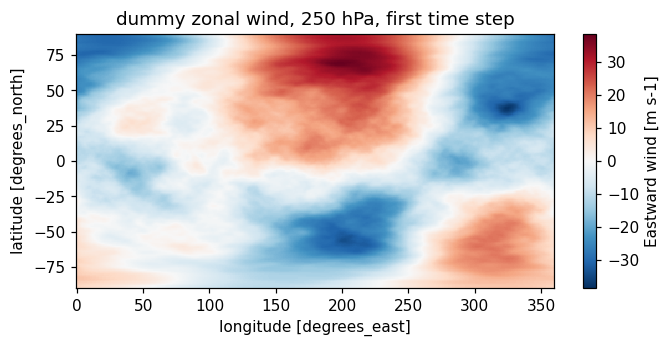

In [4]:
lbox = representative_grid_box_distance(ds["lat"].values, ds["lon"].values)
print(f"representative grid box distance L_box = {lbox:.1f} km")

fig, ax = plt.subplots(figsize=(7, 3))
mesh = ds["ua"].isel(time=0, plev=0).plot(ax=ax, cmap="RdBu_r", add_colorbar=True)
ax.set_title("dummy zonal wind, 250 hPa, first time step")
plt.show()

## 2. Run the metric

`compute_effective_resolution` is the pure-computation entry point: an xarray Dataset
goes in, two dictionaries come out. It performs no file I/O and produces no plots, so it
is the function to use from a notebook or a pipeline.

Note that `levels` is always given in **hPa**, whatever units the vertical coordinate
uses — here it is a CMIP-style Pa axis.

In [5]:
metrics, diagnostics = compute_effective_resolution(
    ds,
    uvar="ua",
    vvar="va",
    levels=(250.0, 500.0),
    model="DUMMY-HR",
    member="r1i1p1f1",
)

result = metrics["DUMMY-HR"]["r1i1p1f1"]
result

{'effective_wavenumber': 54.0,
 'effective_resolution_km': 367.2647553046286,
 'grid_box_distance_km': 133.99631291692674,
 'resolution_ratio': 2.7408571721844357,
 'resolution_ratio_dx_convention': 7.752314770861597,
 'is_upper_limit': False,
 'n_spectra_steepening': 3,
 'steepening_wavenumber': {'div_250': 42.0, 'rot_250': 61.0, 'rot_500': 54.0},
 'steepening_eddy_scale_km': {'div_250': 470.97581333966804,
  'rot_250': 325.45932210795416,
  'rot_500': 367.2647553046286},
 'steepening_wavenumber_range': [42.0, 61.0],
 'criterion': {'fit_window': 20,
  'fit_anchor': 'center',
  'steepening_factor': 0.25,
  'wavenumber_ratio': 2.0,
  'min_wavenumber': 32,
  'n_confirm': 2},
 'reference': 'Klaver et al. (2020), doi:10.1002/asl.952'}

The headline numbers, laid out:

In [6]:
import pandas as pd

summary = pd.Series(
    {
        "effective wavenumber l_eff": result["effective_wavenumber"],
        "effective resolution L_eff (km)": round(result["effective_resolution_km"], 1),
        "grid box distance L_box (km)": round(result["grid_box_distance_km"], 1),
        "ratio L_eff / L_box": round(result["resolution_ratio"], 2),
        "ratio in the dx convention": round(result["resolution_ratio_dx_convention"], 2),
        "spectra showing steepening": f"{result['n_spectra_steepening']} of 3",
        "upper limit only": result["is_upper_limit"],
    },
    name="value",
)
print(summary.to_string())
print()
print("per-spectrum detections (wavenumber -> eddy scale):")
for key, wavenumber in result["steepening_wavenumber"].items():
    scale = result["steepening_eddy_scale_km"][key]
    print(f"  {key:8s}  l = {wavenumber}   ΔS = {scale:.0f} km")

effective wavenumber l_eff           54.0
effective resolution L_eff (km)     367.3
grid box distance L_box (km)        134.0
ratio L_eff / L_box                  2.74
ratio in the dx convention           7.75
spectra showing steepening         3 of 3
upper limit only                    False

per-spectrum detections (wavenumber -> eddy scale):
  div_250   l = 42.0   ΔS = 471 km
  rot_250   l = 61.0   ΔS = 325 km
  rot_500   l = 54.0   ΔS = 367 km


The divergent spectrum at 250 hPa steepens first, exactly as Klaver et al. describe, and
`l_eff` is the second-smallest of the three detections — the two-of-three confirmation
rule.

For context, the ratio `L_eff / L̃_box` lies between 2.7 and 4.8 for the 13 HighResMIP
configurations in the paper's Table 1, so a value near 2.7 here is a plausible result
for a model of this grid spacing.

## 3. Raw kinetic energy spectra

Before examining the diagnostic plots, let's visualize the raw kinetic energy spectra.
This single-panel plot shows:

- **Y-axis**: Raw kinetic energy per unit mass (m²/s²) in log scale
- **X-axis**: Total horizontal wavenumber in log scale
- **Three curves**: Divergent component at 250 hPa (blue), rotational component at
  250 hPa (orange), and rotational component at 500 hPa (green)
- **Reference lines**: k⁻³ (solid black) representing the enstrophy-cascading range,
  and k⁻⁵/³ (dashed black) representing classical energy-cascading turbulence

**Purpose**: Shows how energy is distributed across spatial scales. In a well-resolved
model, the spectra should follow the k⁻³ reference across the resolved range, then roll
off (steepen) at small scales where numerical diffusion and parameterization drain energy.
The point where this roll-off begins indicates the model's effective resolution.

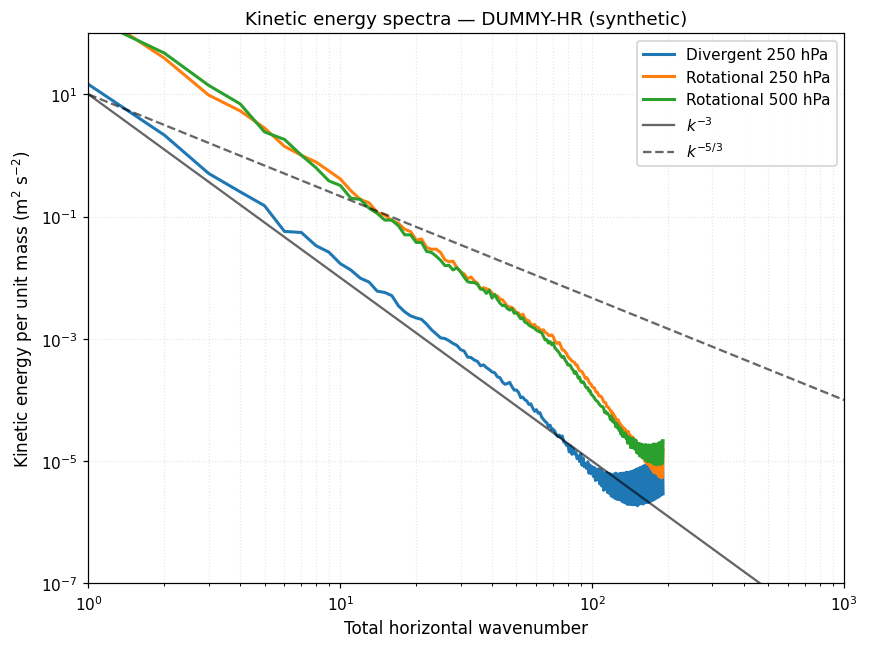

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the kinetic energy spectra
spectra = diagnostics["spectra"]
colors = {"div": "C0", "rot_250": "C1", "rot_500": "C2"}
labels = {"div": "Divergent 250 hPa", "rot_250": "Rotational 250 hPa", 
          "rot_500": "Rotational 500 hPa"}

# Plot divergent at 250 hPa
spec_250 = spectra[250.0]
wavenumber = spec_250["wavenumber"].values
ke_div = spec_250["ke_div"].values
ax.loglog(wavenumber, ke_div, color=colors["div"], linewidth=2, label=labels["div"])

# Plot rotational at 250 hPa
ke_rot_250 = spec_250["ke_rot"].values
ax.loglog(wavenumber, ke_rot_250, color=colors["rot_250"], linewidth=2, label=labels["rot_250"])

# Plot rotational at 500 hPa
spec_500 = spectra[500.0]
ke_rot_500 = spec_500["ke_rot"].values
ax.loglog(wavenumber, ke_rot_500, color=colors["rot_500"], linewidth=2, label=labels["rot_500"])

# Add reference lines for k^-3 and k^-5/3
k_ref = np.logspace(0, 3, 100)  # wavenumbers from 1 to 1000
# Normalize reference lines to intersect the data appropriately
ke_ref_k3 = 1e1 * k_ref**(-3)
ke_ref_k53 = 1e1 * k_ref**(-5/3)

ax.loglog(k_ref, ke_ref_k3, 'k-', linewidth=1.5, alpha=0.6, label=r'$k^{-3}$')
ax.loglog(k_ref, ke_ref_k53, 'k--', linewidth=1.5, alpha=0.6, label=r'$k^{-5/3}$')

ax.set_xlim(1, 1000)
ax.set_ylim(1e-7, 1e2)
ax.set_xlabel("Total horizontal wavenumber", fontsize=11)
ax.set_ylabel(r"Kinetic energy per unit mass (m$^2$ s$^{-2}$)", fontsize=11)
ax.legend(loc="upper right", frameon=True, framealpha=0.9)
ax.grid(True, which="both", alpha=0.3, linestyle=":")
ax.set_title("Kinetic energy spectra — DUMMY-HR (synthetic)", fontsize=12)

plt.tight_layout()
plt.show()

## 4. Compensated spectra and slope analysis (Figure 1 of Klaver et al.)

`plot_spectra_and_slope` reproduces Figure 1 of the paper and provides a **two-panel
diagnostic plot** that makes it much easier to detect where the spectrum steepens:

### Upper panel: Compensated spectra (E × l³)
- The spectra are **multiplied by l³** so that a k⁻³ power law appears as a **flat
  horizontal line** (because k⁻³ × k³ = constant)
- **Why useful**: Any deviation from flat reveals where the spectrum steepens or flattens.
  This transformation amplifies the "roll-off" at small scales, making it visually obvious
  where numerical damping begins to dominate
- A perfectly resolved k⁻³ spectrum would be a horizontal line; downward curvature
  indicates energy is being drained from those scales
- **Reference lines**: 
  - Solid lines show the exact k⁻⁵/³ (light blue) and k⁻³ (orange) power laws
  - Dash-dot lines (-.​) show the same power laws multiplied by 1.1 (10% steeper),
    providing a visual bracket to assess how close the data follows the theoretical slopes

### Lower panel: Slope exponent n(l)
- Shows the local spectral slope at each wavenumber, calculated using a sliding window
- **Purpose**: Quantifies *exactly where* the spectrum steepens beyond the k⁻³ reference
- Horizontal lines mark the theoretical slopes: k⁻⁵/³ ≈ 1.67 and k⁻³ = 3.0
- The dotted "skewed" reference lines show the +25%-per-doubling criterion anchored at
  each detection point
- The dashed black vertical line marks the final effective wavenumber `l_eff` (the
  second-smallest of the three detections, per the two-of-three confirmation rule)

**Key difference from Section 3**: While the raw spectra plot shows the energy
distribution, this compensated view and slope analysis directly reveal where the model
loses its ability to represent scales accurately — which is the whole point of the
effective resolution metric.

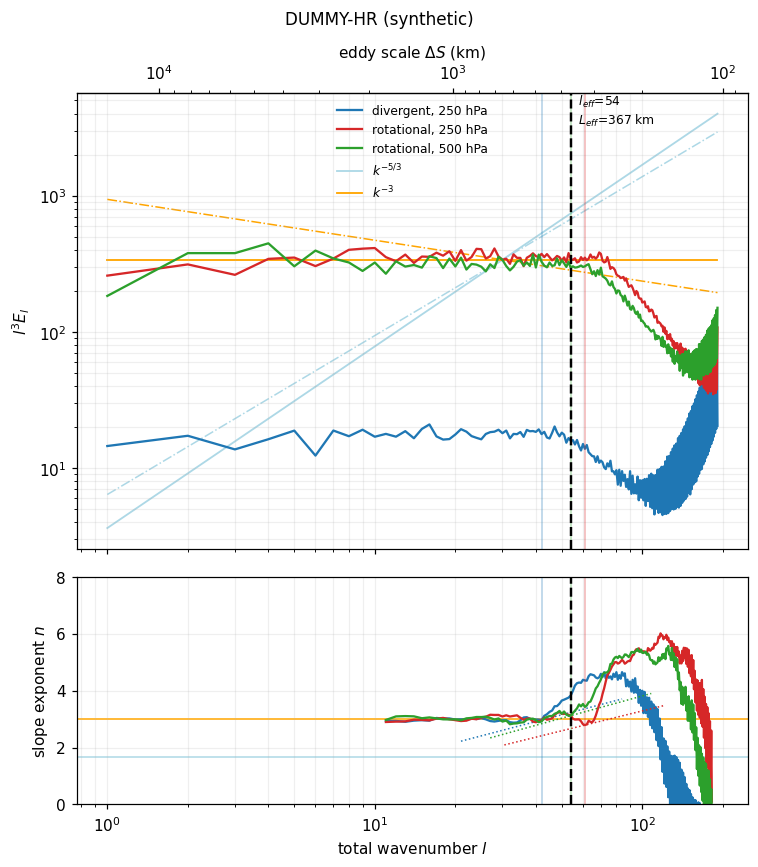

In [8]:
fig = plot_spectra_and_slope(diagnostics, result, title="DUMMY-HR (synthetic)")
plt.show()

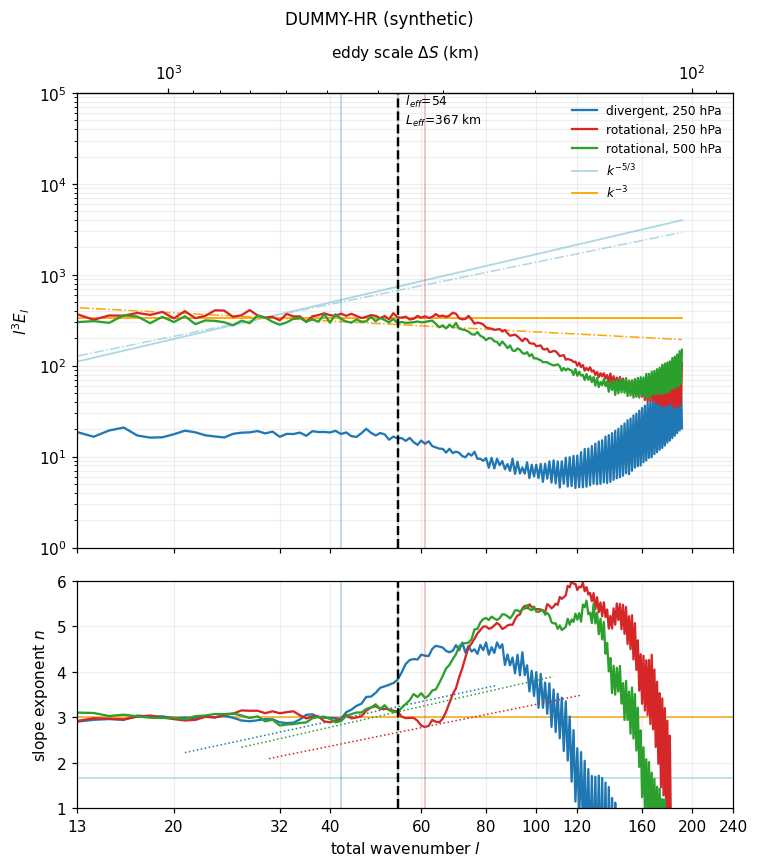

In [15]:
# Match paper Figure 1 axis ranges
fig = plot_spectra_and_slope(
    diagnostics, 
    result,
    figsize=(7,8),
    xlim=(13, 240),          # Wavenumber range
    spec_ylim=(1e0, 1e5),    # Compensated spectrum y-range  
    slope_ylim=(1, 6),       # Slope panel y-range
    xticks=[13, 20, 32, 40, 60, 80, 100, 120, 160, 200, 240],  # Tick positions
    title="DUMMY-HR (synthetic)"
)

Reading the figure: the rotational spectra sit on the `k⁻³` reference line across the
resolved range, then bend downward. The slope exponent leaves 3 and climbs toward 5–6.
The collapse of `n(l)` beyond `l ≈ 150` is the truncation limit of a 192-latitude grid,
not a physical feature — detection is capped well below it.

## 5. Sensitivity to the ad hoc 25% threshold

The authors describe the 25% steepening threshold as "ad hoc and somewhat arbitrary",
and argue that the two-of-three rule makes the final answer only marginally sensitive to
it. That argument was made for their 13 configurations, so it is worth re-checking on
any new model. `steepening_factor` makes the sweep a one-liner:

In [10]:
rows = []
for factor in (0.15, 0.20, 0.25, 0.30, 0.40):
    detections = {
        key: detect_steepening(slope, steepening_factor=factor, min_wavenumber=32)["wavenumber"]
        for key, slope in diagnostics["slopes"].items()
    }
    found = sorted(w for w in detections.values() if w is not None)
    rows.append(
        {"steepening_factor": factor, **detections,
         "l_eff": found[1] if len(found) >= 2 else None}
    )

pd.DataFrame(rows).set_index("steepening_factor")

,div_250,rot_250,rot_500,l_eff
steepening_factor,,,,
0.15,42.0,61.0,41.0,42.0
0.20,42.0,61.0,54.0,54.0
0.25,42.0,61.0,54.0,54.0
0.30,42.0,61.0,54.0,54.0
0.40,42.0,62.0,54.0,54.0


## 6. Figure 2 — effective against nominal resolution

`plot_resolution_scatter` reproduces Figure 2: `L_eff` against `L̃_box` for an ensemble,
with the ratio shaded behind and the spread of the three per-spectrum detections as
error bars. Here we compare the model above against a coarser configuration of the same
synthetic family, the way HighResMIP pairs a low- and high-resolution version of one
model.

DUMMY-LR: L_box = 268 km, l_eff = 32, ratio = 2.30
DUMMY-HR: L_box = 134 km, l_eff = 54, ratio = 2.74


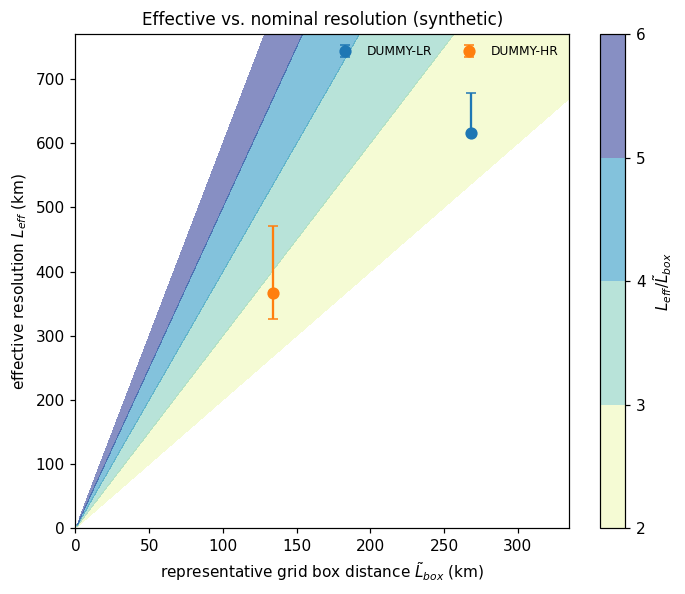

In [11]:
ensemble, labels = [], []
for name, nlat, rolloff, min_wavenumber in (
    ("DUMMY-LR", 96, (28.0, 40.0, 34.0), 16),
    ("DUMMY-HR", 192, (50.0, 70.0, 62.0), 32),
):
    ds_case = make_dummy_dataset(nlat=nlat, nlon=2 * nlat, rolloff=rolloff)
    case_metrics, _ = compute_effective_resolution(
        ds_case, model=name, member="r1i1p1f1", min_wavenumber=min_wavenumber
    )
    ensemble.append(case_metrics[name]["r1i1p1f1"])
    labels.append(name)
    print(f"{name}: L_box = {ensemble[-1]['grid_box_distance_km']:.0f} km, "
          f"l_eff = {ensemble[-1]['effective_wavenumber']:.0f}, "
          f"ratio = {ensemble[-1]['resolution_ratio']:.2f}")

fig = plot_resolution_scatter(
    ensemble, labels=labels, title="Effective vs. nominal resolution (synthetic)"
)
plt.show()

The coarser configuration uses `min_wavenumber=16` because its truncation sits below the
paper's `l = 32` cut-off. **Do not lower it for real data** — below `l ≈ 13` the observed
atmospheric spectrum is shallower than `k⁻³`, so the criterion loses its meaning.

## 7. The file-based API

`process_effective_resolution` is the entry point the driver uses: file paths in, output
files out. It writes the spectra to NetCDF and the metrics to JSON with the standard PMP
provenance block. Here we write the dummy dataset to disk first so the call is a genuine
round trip.

In [12]:
import json
import os
import tempfile

work_dir = tempfile.mkdtemp(prefix="effres_demo_")
input_path = os.path.join(work_dir, "dummy_wind.nc")
ds.to_netcdf(input_path)

file_metrics = process_effective_resolution(
    {
        "model": "DUMMY-HR",
        "exp": "synthetic",
        "member": "r1i1p1f1",
        "input_file": input_path,
        "levels": (250.0, 500.0),
        "output_dir": os.path.join(work_dir, "output"),
        "plot": True,
    }
)

print("output files:")
for name in sorted(os.listdir(os.path.join(work_dir, "output"))):
    print("  ", name)

json_path = os.path.join(
    work_dir, "output", "effective_resolution_DUMMY-HR_synthetic_r1i1p1f1.json"
)
with open(json_path) as handle:
    written = json.load(handle)
print()
print("top-level JSON keys:", sorted(written))
print("json_structure:", written["DIMENSIONS"]["json_structure"])
print("l_eff from JSON:",
      written["RESULTS"]["DUMMY-HR"]["r1i1p1f1"]["effective_wavenumber"])

2026-08-25 15:36:08,375 [WARNING]: dataset.py(_is_decodable:601) >> 'time' does not have a 'units' attribute set so it could not be decoded. Try setting the 'units' attribute (`ds.{coords.name}.attrs['units']`) and try decoding again.
2026-08-25 15:36:08,402 [WARNING]: bounds.py(add_missing_bounds:192) >> Bounds cannot be created for 'time' coordinates because it is not decoded as `cftime.datetime` or `np.datetime`. Try decoding 'time' first then adding bounds.
INFO::2026-08-25 15:36::pcmdi_metrics:: Results saved to a json file: /var/folders/wh/jt7ywcnn01z8xcrr1p_dzp8r001rcz/T/effres_demo_xqwawch6/output/effective_resolution_DUMMY-HR_synthetic_r1i1p1f1.json


output files:
   effective_resolution_DUMMY-HR_synthetic_r1i1p1f1.json
   ke_spectra_DUMMY-HR_synthetic_r1i1p1f1.nc
   ke_spectra_DUMMY-HR_synthetic_r1i1p1f1.png

top-level JSON keys: ['DIMENSIONS', 'REFERENCE', 'RESULTS', 'json_structure', 'provenance']
json_structure: ['model', 'realization', 'metric']
l_eff from JSON: 54.0


## Caveats worth carrying forward

- The result describes **scales smaller than `L_eff` as dynamically unreliable**; per the
  authors they "should be disregarded in the context of interpretational climate
  studies". It says nothing about the fidelity of larger scales.
- Input must be on the model's **native grid** and at **6-hourly or finer** frequency.
  Regridding overwrites the scales being measured; daily means smooth away the transient
  energy the diagnostic lives on.
- For reduced Gaussian and octahedral grids the file's rectilinear coordinates
  misrepresent the mesh — pass `grid_box_distance_km` explicitly.
- The spectrum is global and time-mean, which may obscure a phenomenon-dependent
  effective resolution (midlatitude storms versus equatorial updraughts).

See `README.md` for the full method description and the reference values of Klaver et
al. Table 1.